## Data Cleaning

In [2]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Customer Table

In [4]:
# load dataset
df_customer = pd.read_csv('raw_data/customers.csv')

# check dataset info
df_customer.info()

# observation: all data types are correct, except for columns 2-5

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     1000 non-null   int64 
 1   age             1000 non-null   int64 
 2   gender          1000 non-null   object
 3   region          1000 non-null   object
 4   income_bracket  971 non-null    object
 5   signup_channel  1000 non-null   object
 6   tenure_months   1000 non-null   int64 
 7   churned         1000 non-null   bool  
dtypes: bool(1), int64(3), object(4)
memory usage: 55.8+ KB


In [5]:
# check first rows of the dataset
df_customer.head()

,customer_id,age,gender,region,income_bracket,signup_channel,tenure_months,churned
0,1,33,Male,Luzon,Mid,App,39,False
1,2,35,Male,Mindanao,Low,Web,15,False
2,3,33,Female,Luzon,Mid,App,33,False
3,4,46,Male,NCR,Low,Web,15,False
4,5,46,Female,NCR,Mid,Web,34,False


In [6]:
# convert objects into categorical data types
for col in df_customer.select_dtypes(include=['object']).columns:
    df_customer[col] = df_customer[col].astype('category')

df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   customer_id     1000 non-null   int64   
 1   age             1000 non-null   int64   
 2   gender          1000 non-null   category
 3   region          1000 non-null   category
 4   income_bracket  971 non-null    category
 5   signup_channel  1000 non-null   category
 6   tenure_months   1000 non-null   int64   
 7   churned         1000 non-null   bool    
dtypes: bool(1), category(4), int64(3)
memory usage: 29.0 KB


In [7]:
# check if each categorical columns' values are inconsistent or not
for col in df_customer.select_dtypes(include=['category']).columns:
    print(f'{col}: {df_customer[col].unique()}')
    print()

# observation: all categorical columns' values are consistent

gender: ['Male', 'Female']
Categories (2, object): ['Female', 'Male']

region: ['Luzon', 'Mindanao', 'NCR', 'Visayas']
Categories (4, object): ['Luzon', 'Mindanao', 'NCR', 'Visayas']

income_bracket: ['Mid', 'Low', NaN, 'High']
Categories (3, object): ['High', 'Low', 'Mid']

signup_channel: ['App', 'Web', 'Store']
Categories (3, object): ['App', 'Store', 'Web']



In [8]:
# check for missing values
df_customer.isnull().sum()

# observation: as expected, there are 29 or 3% missing values for income_bracket column, so let's deal with it

,0
customer_id,0
age,0
gender,0
region,0
income_bracket,29
signup_channel,0
tenure_months,0
churned,0


In [9]:
# check the distribution for category counts
df_customer['income_bracket'].value_counts(dropna=False)

,count
income_bracket,
Mid,410
Low,344
High,217
NaN,29


In [10]:
# impute missing income_bracket values with the mode
df_customer['income_bracket'].fillna(df_customer['income_bracket'].mode()[0], inplace=True)

# verify that there are no more missing values in the column
df_customer['income_bracket'].isnull().sum()

/tmp/ipykernel_28524/3759089536.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_customer['income_bracket'].fillna(df_customer['income_bracket'].mode()[0], inplace=True)


np.int64(0)

In [11]:
# check for duplicate data
df_customer.duplicated().sum()

# observation: there are no duplicate data

np.int64(0)

In [12]:
# check for descriptive statistics
df_customer.describe()

,customer_id,age,tenure_months
count,1000.000000,1000.000000,1000.000000
mean,500.500000,34.335000,30.476000
std,288.819436,9.661269,7.138514
min,1.000000,18.000000,8.000000
25%,250.750000,27.000000,26.000000
50%,500.500000,34.000000,30.000000
75%,750.250000,40.000000,35.000000
max,1000.000000,76.000000,52.000000


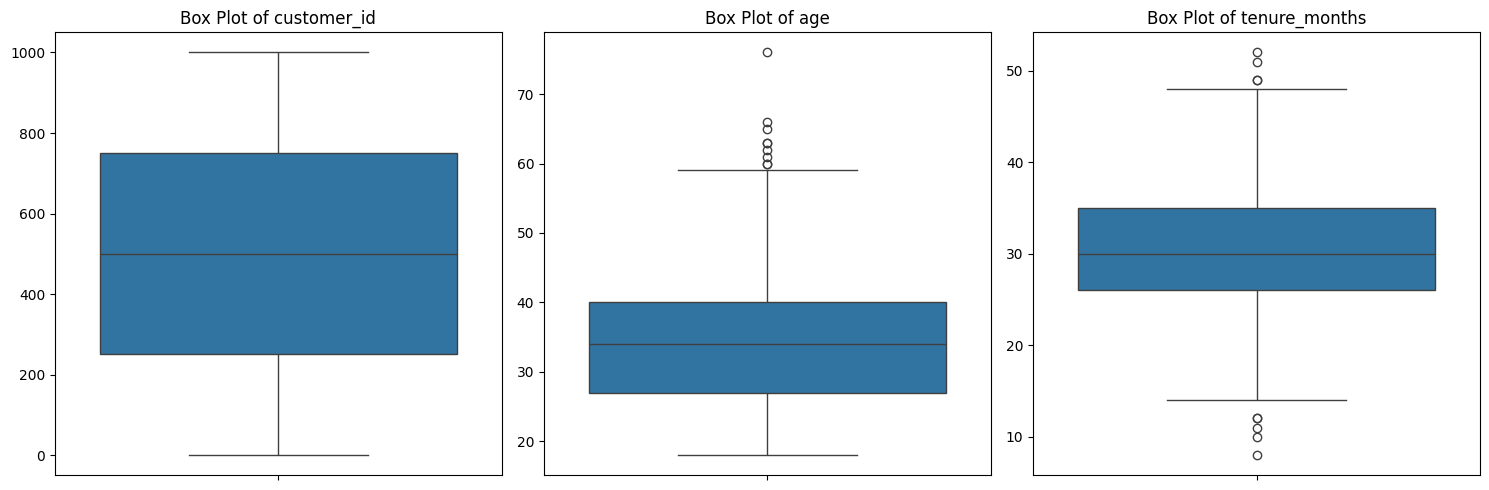

In [13]:
# check for outliers

# select only numerical columns for box plots
numerical_cols = df_customer.select_dtypes(include=['int64', 'float64']).columns

# create box plots for each numerical column
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, len(numerical_cols), i + 1) # adjust subplot layout as needed
    sns.boxplot(y=df_customer[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

# observation: no outliers were injected during the synthetic data generation phase, so it's all good

In [15]:
# save the cleaned data to a new CSV file
df_customer.to_csv('clean_data/cleaned_customers.csv', index=False)

### Subscriptions Table

In [16]:
# load the dataset
df_subscriptions = pd.read_csv('raw_data/subscriptions.csv')

# check dataset info
df_subscriptions.info()

# observation: no null values, but object values needd to be converted

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   subscription_id  1000 non-null   int64  
 1   customer_id      1000 non-null   int64  
 2   plan_type        1000 non-null   object 
 3   monthly_fee      1000 non-null   float64
 4   contract_type    1000 non-null   object 
 5   discount_pct     1000 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 47.0+ KB


In [17]:
# check first 5 rows of the dataset
df_subscriptions.head()

,subscription_id,customer_id,plan_type,monthly_fee,contract_type,discount_pct
0,1,1,Basic,287.96,Postpaid,0.15
1,2,2,Basic,329.86,Prepaid,0.15
2,3,3,Basic,313.36,Postpaid,0.00
3,4,4,Basic,326.43,Postpaid,0.00
4,5,5,Standard,496.70,Postpaid,0.10


In [18]:
# check for descriptive info
df_subscriptions.describe()

,subscription_id,customer_id,monthly_fee,discount_pct
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,500.500000,536.423300,0.045600
std,288.819436,288.819436,275.862999,0.054577
min,1.000000,1.000000,155.190000,0.000000
25%,250.750000,250.750000,302.977500,0.000000
50%,500.500000,500.500000,503.855000,0.000000
75%,750.250000,750.250000,655.812500,0.100000
max,1000.000000,1000.000000,1126.980000,0.150000


In [19]:
# check for duplicate values
df_subscriptions.duplicated().sum()

# observation: there are no duplicate data

np.int64(0)

In [20]:
# check categorical columns if their values have inconsistencies
for col in df_subscriptions.select_dtypes(include=['object']).columns:
    print(f'{col}: {df_subscriptions[col].unique()}')
    print()

# observation: each categorical column have no inconsistent data

plan_type: ['Basic' 'Standard' 'Premium']

contract_type: ['Postpaid' 'Prepaid']



In [21]:
# convert objects into categories
df_subscriptions['plan_type'] = df_subscriptions['plan_type'].astype('category')
df_subscriptions['contract_type'] = df_subscriptions['contract_type'].astype('category')

df_subscriptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   subscription_id  1000 non-null   int64   
 1   customer_id      1000 non-null   int64   
 2   plan_type        1000 non-null   category
 3   monthly_fee      1000 non-null   float64 
 4   contract_type    1000 non-null   category
 5   discount_pct     1000 non-null   float64 
dtypes: category(2), float64(2), int64(2)
memory usage: 33.6 KB


In [22]:
# check for descriptive statistics
df_subscriptions.describe()

,subscription_id,customer_id,monthly_fee,discount_pct
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,500.500000,536.423300,0.045600
std,288.819436,288.819436,275.862999,0.054577
min,1.000000,1.000000,155.190000,0.000000
25%,250.750000,250.750000,302.977500,0.000000
50%,500.500000,500.500000,503.855000,0.000000
75%,750.250000,750.250000,655.812500,0.100000
max,1000.000000,1000.000000,1126.980000,0.150000


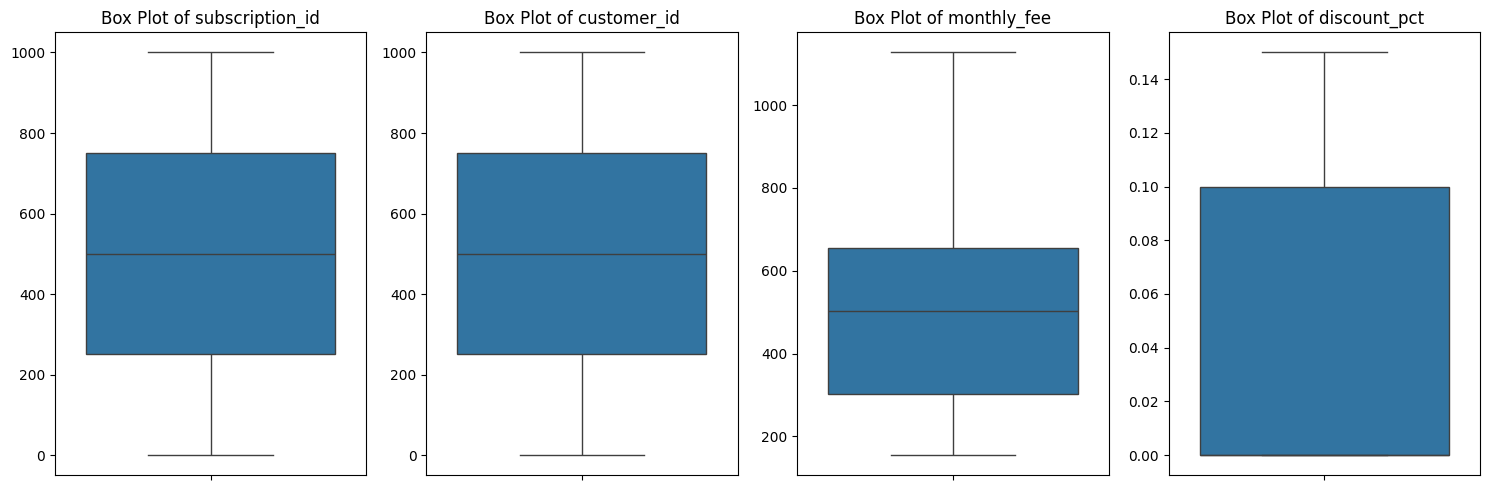

In [23]:
# check for outliers

# select only numerical columns for box plots
numerical_cols_subscriptions = df_subscriptions.select_dtypes(include=['int64', 'float64']).columns

# create box plots for each numerical column
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols_subscriptions):
    plt.subplot(1, len(numerical_cols_subscriptions), i + 1) # adjust subplot layout as needed
    sns.boxplot(y=df_subscriptions[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

# observation: no outliers were injected during the synthetic data generation phase, so it's all good

In [24]:
# save the cleaned data to a new CSV file
df_subscriptions.to_csv('clean_data/cleaned_subscriptions.csv', index=False)

### Monthly Usage Table



In [25]:
# load dataset
df_usage_monthly = pd.read_csv('raw_data/usage_monthly.csv')

# check dataset info
df_usage_monthly.info()

# observation: all data types are correct but the data_usage_gb has missing/null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   usage_id       12000 non-null  int64  
 1   customer_id    12000 non-null  int64  
 2   month          12000 non-null  int64  
 3   data_usage_gb  11407 non-null  float64
 4   call_minutes   12000 non-null  int64  
 5   sms_count      12000 non-null  int64  
 6   roaming_usage  12000 non-null  float64
dtypes: float64(2), int64(5)
memory usage: 656.4 KB


In [26]:
# check the first 5 rows of the dataset
df_usage_monthly.head()

,usage_id,customer_id,month,data_usage_gb,call_minutes,sms_count,roaming_usage
0,1,1,1,17.049,104,56,0.121
1,2,2,1,8.184,142,45,0.045
2,3,3,1,13.870,141,45,0.147
3,4,4,1,17.335,75,44,0.364
4,5,5,1,9.878,118,44,0.585


In [27]:
# check for descriptive info
df_usage_monthly.describe()

,usage_id,customer_id,month,data_usage_gb,call_minutes,sms_count,roaming_usage
count,12000.00000,12000.000000,12000.000000,11407.000000,12000.000000,12000.000000,12000.000000
mean,6000.50000,500.500000,6.500000,17.468360,126.038417,49.948250,0.500815
std,3464.24595,288.687019,3.452196,10.777288,26.953107,7.050606,0.496105
min,1.00000,1.000000,1.000000,0.000000,74.000000,27.000000,0.000000
25%,3000.75000,250.750000,3.750000,11.980500,111.000000,45.000000,0.146000
50%,6000.50000,500.500000,6.500000,16.021000,124.000000,50.000000,0.347000
75%,9000.25000,750.250000,9.250000,21.201500,137.000000,55.000000,0.702000
max,12000.00000,1000.000000,12.000000,118.815000,370.000000,79.000000,4.312000


In [28]:
# check for missing values
df_usage_monthly.isnull().sum()

# observation: as expected, 594 or 5% of data_usage_gb is missing, so let's deal with it

,0
usage_id,0
customer_id,0
month,0
data_usage_gb,593
call_minutes,0
sms_count,0
roaming_usage,0


In [29]:
# impute missing data_usage_gb values with the mean
df_usage_monthly['data_usage_gb'].fillna(df_usage_monthly['data_usage_gb'].mean(), inplace=True)

# verify that there are no more missing values in the column
df_usage_monthly['data_usage_gb'].isnull().sum()

/tmp/ipykernel_28524/2639099202.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_usage_monthly['data_usage_gb'].fillna(df_usage_monthly['data_usage_gb'].mean(), inplace=True)


np.int64(0)

In [30]:
# check for duplicate data
df_usage_monthly.duplicated().sum()

# observation: there are no duplicate data

np.int64(0)

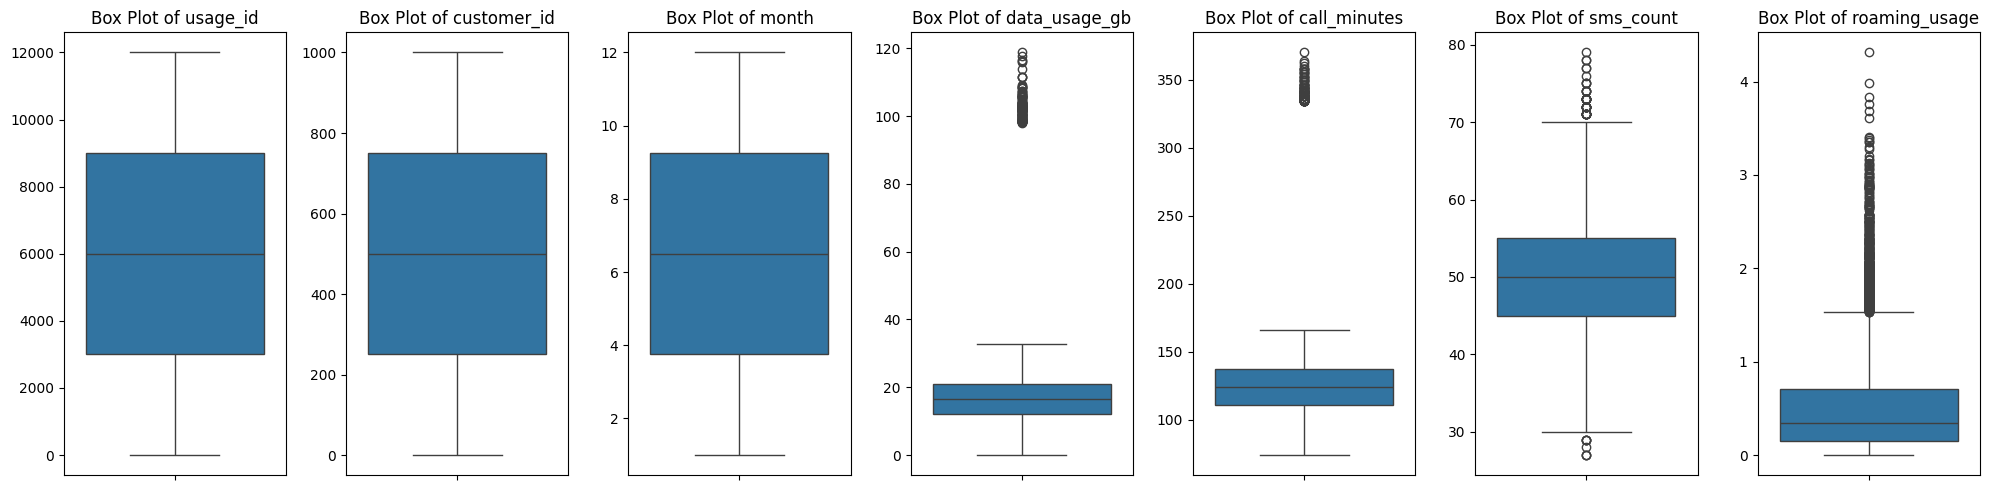

In [31]:
# check for outliers

# select only numerical columns for box plots
numerical_cols_usage = df_usage_monthly.select_dtypes(include=['int64', 'float64']).columns

# create box plots for each numerical column
plt.figure(figsize=(20, 5))
for i, col in enumerate(numerical_cols_usage):
    plt.subplot(1, len(numerical_cols_usage), i + 1) # adjust subplot layout as needed
    sns.boxplot(y=df_usage_monthly[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

# observation: as expected, there were outliers, such as top 1% users × 3 & call_minutes outliers × 2

In [32]:
# cap outliers in 'data_usage_gb' at the 99th percentile
upper_bound_data_usage = df_usage_monthly['data_usage_gb'].quantile(0.99)
df_usage_monthly['data_usage_gb'] = np.where(
    df_usage_monthly['data_usage_gb'] > upper_bound_data_usage,
    upper_bound_data_usage,
    df_usage_monthly['data_usage_gb']
)

# cap outliers in 'call_minutes' at the 99th percentile
upper_bound_call_minutes = df_usage_monthly['call_minutes'].quantile(0.99)
df_usage_monthly['call_minutes'] = np.where(
    df_usage_monthly['call_minutes'] > upper_bound_call_minutes,
    upper_bound_call_minutes,
    df_usage_monthly['call_minutes']
)

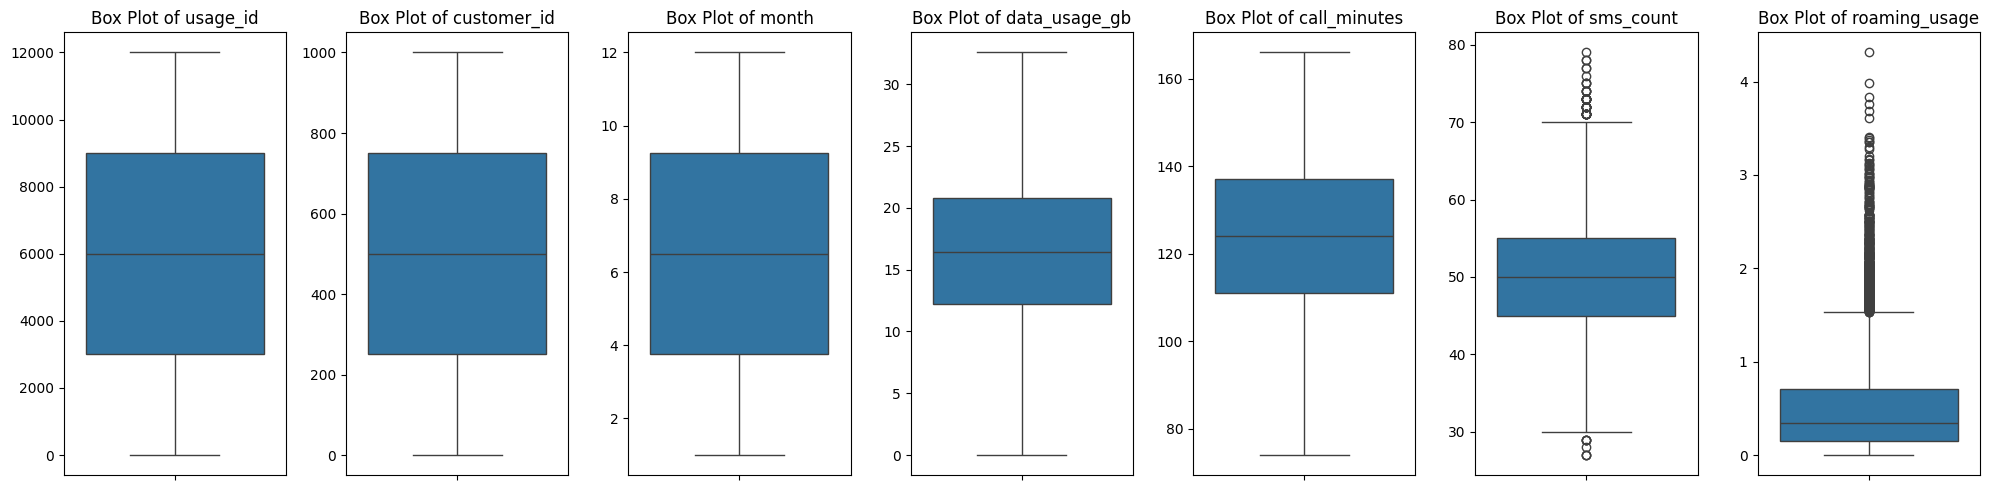

In [33]:
# re-check for outliers after capping using box plots
numerical_cols_usage = df_usage_monthly.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(20, 5))
for i, col in enumerate(numerical_cols_usage):
    plt.subplot(1, len(numerical_cols_usage), i + 1)
    sns.boxplot(y=df_usage_monthly[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

In [34]:
# save the cleaned data to a new CSV file
df_usage_monthly.to_csv('clean_data/cleaned_usage_monthly.csv', index=False)

### Support Tickets Table

In [35]:
# load the dataset
df_support_tickets = pd.read_csv('raw_data/support_tickets.csv')

# check dataset info
df_support_tickets.info()

# observation: all data types are correct and no missing values, except for issue_type that should be categorical

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ticket_id     12000 non-null  int64 
 1   customer_id   12000 non-null  int64 
 2   month         12000 non-null  int64 
 3   ticket_count  12000 non-null  int64 
 4   issue_type    12000 non-null  object
dtypes: int64(4), object(1)
memory usage: 468.9+ KB


In [36]:
# check the first 5 rows of the datast
df_support_tickets.head()

,ticket_id,customer_id,month,ticket_count,issue_type
0,1,1,1,6,Service
1,2,2,1,3,Technical
2,3,3,1,2,Technical
3,4,4,1,4,Technical
4,5,5,1,4,Technical


In [37]:
# check for descriptive info
df_support_tickets.describe()

,ticket_id,customer_id,month,ticket_count
count,12000.00000,12000.000000,12000.000000,12000.000000
mean,6000.50000,500.500000,6.500000,3.964583
std,3464.24595,288.687019,3.452196,2.123371
min,1.00000,1.000000,1.000000,0.000000
25%,3000.75000,250.750000,3.750000,2.000000
50%,6000.50000,500.500000,6.500000,4.000000
75%,9000.25000,750.250000,9.250000,5.000000
max,12000.00000,1000.000000,12.000000,14.000000


In [38]:
# check issue_type if there are categorical value inconsistencies
df_support_tickets['issue_type'].unique()

# observation: no value inconsistencies, so let's go ahead convert it into category
df_support_tickets['issue_type'] = df_support_tickets['issue_type'].astype('category')

# check dataset info again
df_support_tickets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   ticket_id     12000 non-null  int64   
 1   customer_id   12000 non-null  int64   
 2   month         12000 non-null  int64   
 3   ticket_count  12000 non-null  int64   
 4   issue_type    12000 non-null  category
dtypes: category(1), int64(4)
memory usage: 387.0 KB


In [39]:
# check for duplciate values
df_support_tickets.duplicated().sum()

# observation: there are no duplicate data

np.int64(0)

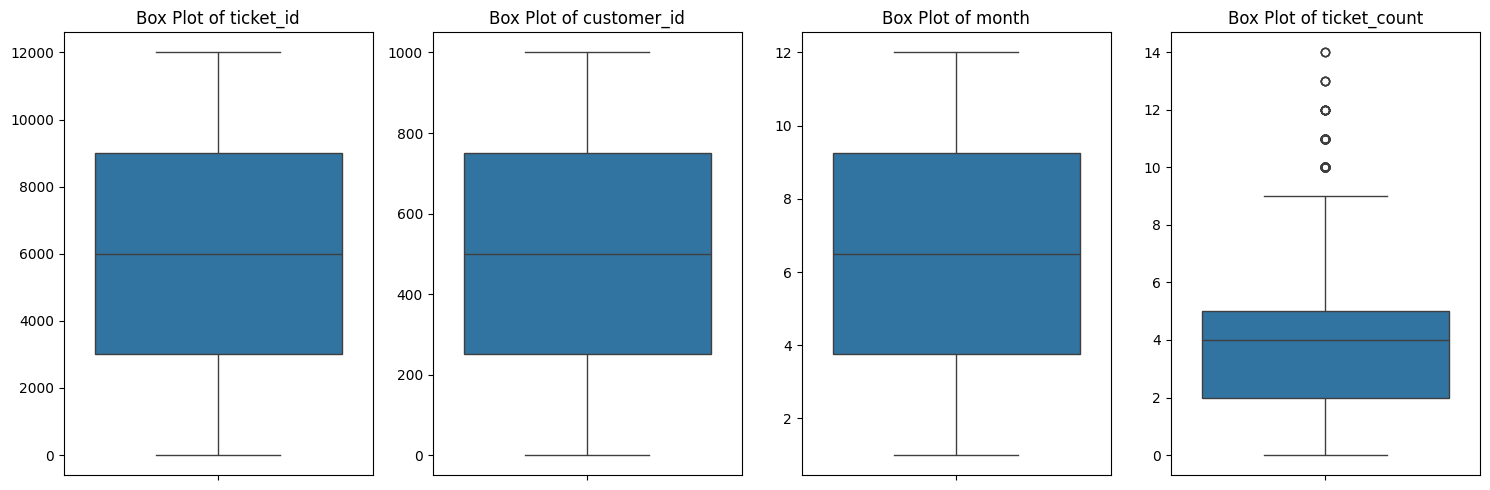

In [40]:
# check for outliers

# select only numerical columns for box plots
numerical_cols_support_tickets = df_support_tickets.select_dtypes(include=['int64']).columns

# create box plots for each numerical column
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols_support_tickets):
    plt.subplot(1, len(numerical_cols_support_tickets), i + 1) # adjust subplot layout as needed
    sns.boxplot(y=df_support_tickets[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

# observation: no outliers were injected during the synthetic data generation phase, so it's all good

In [41]:
# save the cleaned data to a new CSV file
df_support_tickets.to_csv('clean_data/cleaned_support_tickets.csv', index=False)

### Payments Table

In [42]:
# load dataset
df_payments = pd.read_csv('raw_data/payments.csv')

# check dataset info
df_payments.info()

# observation: all data types are correct and there seems to be no missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   payment_id     12000 non-null  int64  
 1   customer_id    12000 non-null  int64  
 2   billing_month  12000 non-null  int64  
 3   amount_due     12000 non-null  float64
 4   amount_paid    12000 non-null  float64
 5   delay_days     12000 non-null  float64
dtypes: float64(3), int64(3)
memory usage: 562.6 KB


In [43]:
# check the first 5 rows of the dataset
df_payments.head()

,payment_id,customer_id,billing_month,amount_due,amount_paid,delay_days
0,1,1,1,244.77,268.02,2.4
1,2,2,1,280.38,268.93,1.1
2,3,3,1,313.36,324.08,0.7
3,4,4,1,326.43,319.97,2.1
4,5,5,1,447.03,449.06,1.8


In [44]:
# check for duplicate values
df_payments.duplicated().sum()

# observation: there are no duplicate data

np.int64(0)

In [45]:
# check descriptive info of the dataset
df_payments.describe()

,payment_id,customer_id,billing_month,amount_due,amount_paid,delay_days
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,6000.50000,500.500000,6.500000,511.854180,511.757588,1.474058
std,3464.24595,288.687019,3.452196,264.930068,265.566790,1.987714
min,1.00000,1.000000,1.000000,144.200000,113.120000,0.000000
25%,3000.75000,250.750000,3.750000,286.927500,287.157500,0.300000
50%,6000.50000,500.500000,6.500000,465.125000,461.650000,0.800000
75%,9000.25000,750.250000,9.250000,642.812500,640.647500,1.900000
max,12000.00000,1000.000000,12.000000,1126.980000,1176.240000,24.900000


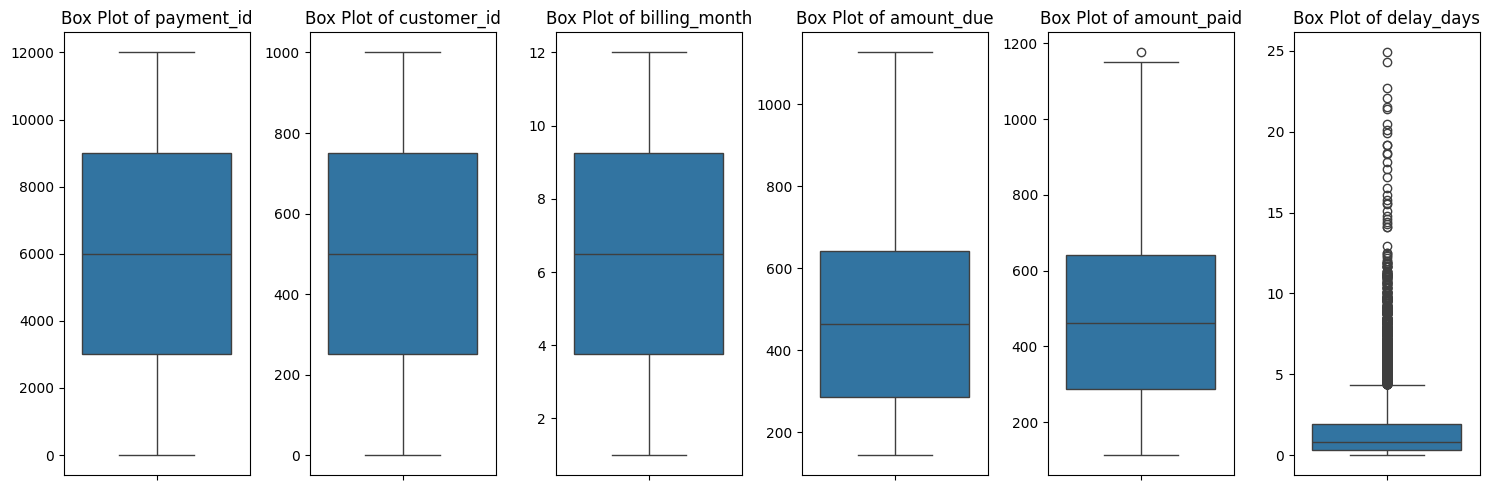

In [46]:
# check for outliers

# select only numerical columns for box plots
numerical_cols_payments = df_payments.select_dtypes(include=['int64', 'float64']).columns

# create box plots for each numerical column
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols_payments):
    plt.subplot(1, len(numerical_cols_payments), i + 1) # adjust subplot layout as needed
    sns.boxplot(y=df_payments[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

# observation: no outliers were injected during the synthetic data generation phase, so it's all good

In [47]:
# save the cleaned data to a new CSV file
df_payments.to_csv('clean_data/cleaned_payments.csv', index=False)

# Exploratory Data Analysis

In [48]:
# import library and cleaned datasets
import matplotlib.gridspec as gridspec
from scipy.special import expit

customers = pd.read_csv('clean_data/cleaned_customers.csv')
subscriptions = pd.read_csv('clean_data/cleaned_subscriptions.csv')
usage_monthly = pd.read_csv('clean_data/cleaned_usage_monthly.csv')
support_tickets = pd.read_csv('clean_data/cleaned_support_tickets.csv')
payments = pd.read_csv('clean_data/cleaned_payments.csv')

In [49]:
# prepare other variables for #7
avg_tickets = support_tickets.groupby("customer_id")["ticket_count"].mean()

# given the user's description, generate CSAT as a random variable
# assume N_CUSTOMERS is the number of unique customer IDs
N_CUSTOMERS = customers['customer_id'].nunique()
rng = np.random.default_rng(42) # for reproducibility
CSAT = pd.Series(rng.beta(2, 2, N_CUSTOMERS), index=customers['customer_id'].unique())

In [50]:
# prepare other variables for #8

# define constants for churn probability
CHURN_INTERCEPT   = -1.5
CHURN_TENURE      = -0.02
CHURN_CSAT        = -2.0
CHURN_PROPENSITY  =  1.5
CHURN_TICKETS     =  0.3

# get tenure for each customer to ensure alignment with customer_id
tenure = customers.set_index('customer_id')['tenure_months']

# generate propensity_to_churn (assuming it's a latent random variable if not explicitly provided)
propensity_to_churn = pd.Series(rng.random(N_CUSTOMERS), index=customers['customer_id'].unique())

# calculate logit_p
logit_p = (
    CHURN_INTERCEPT
    + CHURN_TENURE     * tenure
    + CHURN_CSAT       * CSAT
    + CHURN_PROPENSITY * propensity_to_churn
    + CHURN_TICKETS    * avg_tickets
)

# calculate churn_prob using expit (logistic sigmoid function)
churn_prob = expit(logit_p)

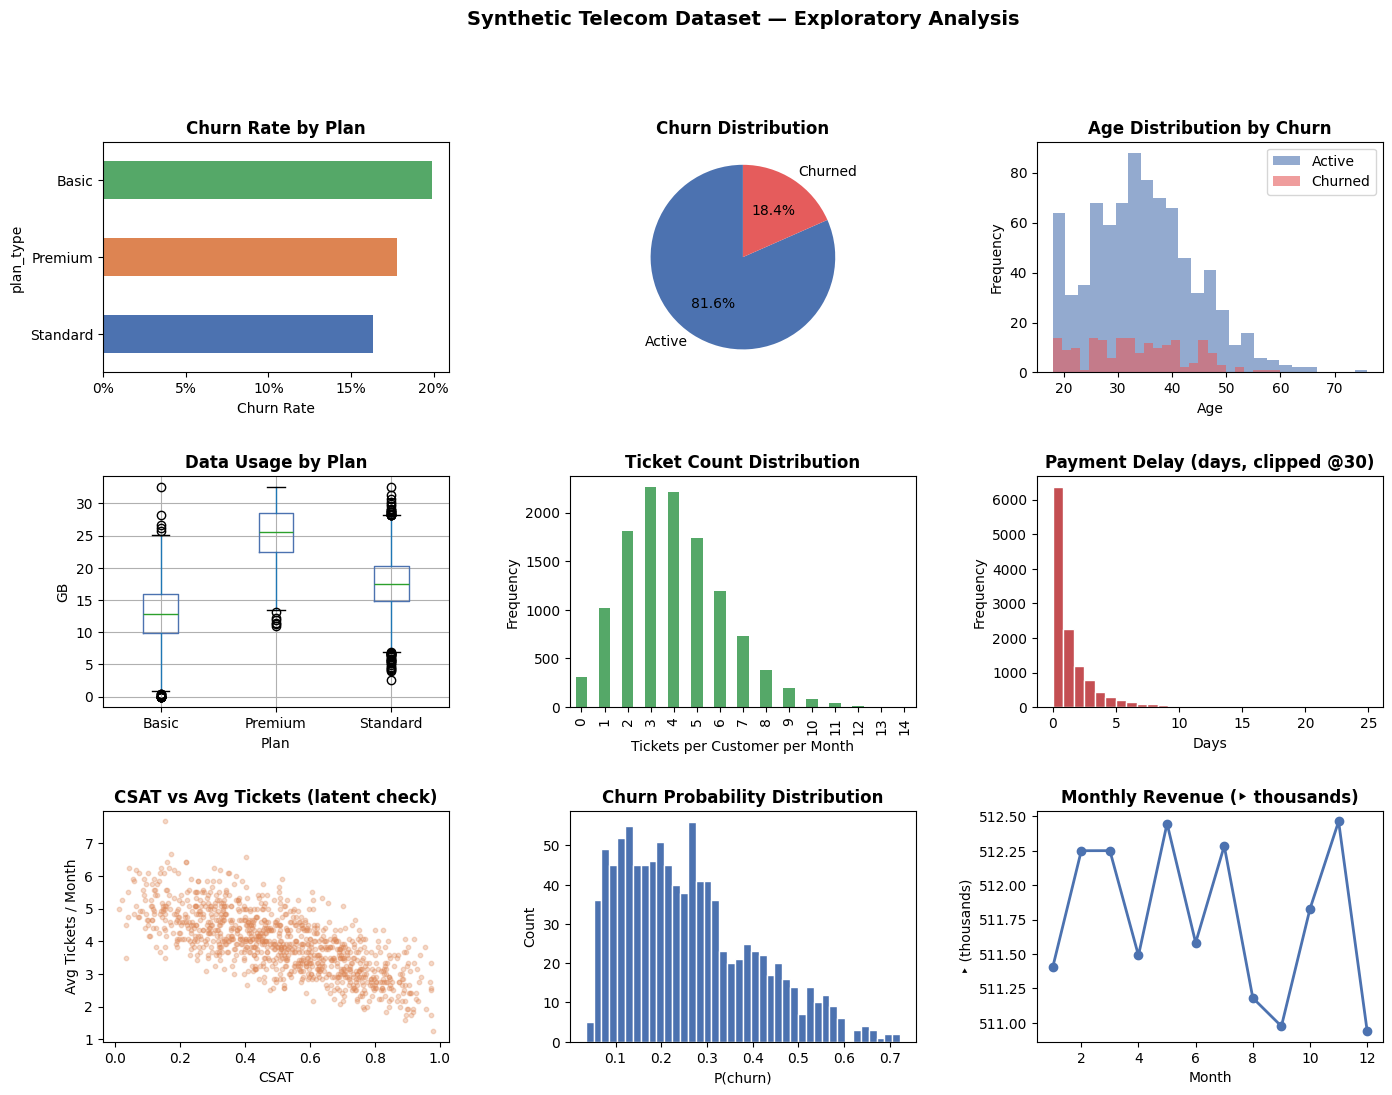

In [51]:
# create EDA
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# churn rate by plan
ax1 = fig.add_subplot(gs[0, 0])
churn_by_plan = customers.merge(
    subscriptions[["customer_id", "plan_type"]], on="customer_id"
).groupby("plan_type")["churned"].mean()
churn_by_plan.sort_values().plot(kind="barh", ax=ax1, color=["#4C72B0","#DD8452","#55A868"])
ax1.set_title("Churn Rate by Plan", fontweight="bold")
ax1.set_xlabel("Churn Rate")
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

# churn distribution
ax2 = fig.add_subplot(gs[0, 1])
customers["churned"].value_counts().plot(
    kind="pie", ax=ax2, labels=["Active", "Churned"],
    colors=["#4C72B0","#E55C5C"], autopct="%1.1f%%", startangle=90
)
ax2.set_title("Churn Distribution", fontweight="bold")
ax2.set_ylabel("")

# age distribution by churn
ax3 = fig.add_subplot(gs[0, 2])
customers[customers.churned == False]["age"].plot(
    kind="hist", ax=ax3, alpha=0.6, bins=25, label="Active", color="#4C72B0")
customers[customers.churned == True]["age"].plot(
    kind="hist", ax=ax3, alpha=0.6, bins=25, label="Churned", color="#E55C5C")
ax3.set_title("Age Distribution by Churn", fontweight="bold")
ax3.set_xlabel("Age")
ax3.legend()

# data usage by plan
ax4 = fig.add_subplot(gs[1, 0])
_ug = usage_monthly.merge(subscriptions[["customer_id","plan_type"]], on="customer_id")
_ug.boxplot(column="data_usage_gb", by="plan_type", ax=ax4,
            boxprops=dict(color="#4C72B0"))
ax4.set_title("Data Usage (GB) by Plan", fontweight="bold")
ax4.set_xlabel("Plan")
ax4.set_ylabel("GB")
plt.sca(ax4); plt.title("Data Usage by Plan", fontweight="bold")

# monthly ticket counts distribution
ax5 = fig.add_subplot(gs[1, 1])
support_tickets["ticket_count"].value_counts().sort_index().plot(
    kind="bar", ax=ax5, color="#55A868")
ax5.set_title("Ticket Count Distribution", fontweight="bold")
ax5.set_xlabel("Tickets per Customer per Month")
ax5.set_ylabel("Frequency")

# payment delay distribution
ax6 = fig.add_subplot(gs[1, 2])
payments["delay_days"].clip(0, 30).plot(
    kind="hist", ax=ax6, bins=30, color="#C44E52", edgecolor="white")
ax6.set_title("Payment Delay (days, clipped @30)", fontweight="bold")
ax6.set_xlabel("Days")

# average tickets vs CSAT (latent check)
_agg = pd.DataFrame({"CSAT": CSAT, "avg_tickets": avg_tickets})
ax7 = fig.add_subplot(gs[2, 0])
ax7.scatter(_agg["CSAT"], _agg["avg_tickets"], alpha=0.3, s=10, color="#DD8452")
ax7.set_title("CSAT vs Avg Tickets (latent check)", fontweight="bold")
ax7.set_xlabel("CSAT")
ax7.set_ylabel("Avg Tickets / Month")

# churn probability distribution
ax8 = fig.add_subplot(gs[2, 1])
ax8.hist(churn_prob, bins=40, color="#4C72B0", edgecolor="white")
ax8.set_title("Churn Probability Distribution", fontweight="bold")
ax8.set_xlabel("P(churn)")
ax8.set_ylabel("Count")

# monthly revenue over time (simulated)
ax9 = fig.add_subplot(gs[2, 2])
monthly_rev = payments.groupby("billing_month")["amount_paid"].sum() / 1_000
monthly_rev.plot(ax=ax9, marker="o", color="#4C72B0", linewidth=2)
ax9.set_title("Monthly Revenue (‣ thousands)", fontweight="bold")
ax9.set_xlabel("Month")
ax9.set_ylabel("‣ (thousands)")

plt.suptitle("Synthetic Telecom Dataset — Exploratory Analysis",
             fontsize=14, fontweight="bold", y=1.01)
# plt.savefig("eda_overview.png", dpi=120, bbox_inches="tight")
plt.show()

# Stretch Tasks

Machine Learning Methods Used


*   Logistic Regression for Churn Predicition
*   Decision Tree Classifier for Churn Predicition
*   Clustering for Customer Segmentation



In [52]:
# prepare data

# aggregate monthly data by customer_id

# usage data: average all numerical usage metrics
df_usage_agg = usage_monthly.groupby('customer_id')[['data_usage_gb', 'call_minutes', 'sms_count', 'roaming_usage']].mean().reset_index()
df_usage_agg.rename(columns={col: f'avg_{col}' for col in df_usage_agg.columns if col not in ['customer_id']}, inplace=True)

# support tickets data: average ticket count
df_support_agg = support_tickets.groupby('customer_id')[['ticket_count']].mean().reset_index()
df_support_agg.rename(columns={'ticket_count': 'avg_ticket_count'}, inplace=True)

# payments data: average all numerical payment metrics
df_payments_agg = payments.groupby('customer_id')[['amount_due', 'amount_paid', 'delay_days']].mean().reset_index()
df_payments_agg.rename(columns={col: f'avg_{col}' for col in df_payments_agg.columns if col not in ['customer_id']}, inplace=True)

In [53]:
# merge data

# merge customers and subscriptions (one-to-one or one-to-many if a customer can have multiple subscriptions, but here it's one-to-one with customer_id as unique key)
df_merged = customers.merge(subscriptions, on='customer_id', how='left')

# merge with aggregated monthly dataframes using left joins to keep all customers
df_merged = df_merged.merge(df_usage_agg, on='customer_id', how='left')
df_merged = df_merged.merge(df_support_agg, on='customer_id', how='left')
df_merged = df_merged.merge(df_payments_agg, on='customer_id', how='left')

# fill any NaN values introduced by left joins with 0 (assuming 0 for no usage/tickets/payments for a customer for a given month)
df_merged.fillna(0, inplace=True)

# check merged data
df_merged.head()

,customer_id,age,gender,region,income_bracket,signup_channel,tenure_months,churned,subscription_id,plan_type,...,contract_type,discount_pct,avg_data_usage_gb,avg_call_minutes,avg_sms_count,avg_roaming_usage,avg_ticket_count,avg_amount_due,avg_amount_paid,avg_delay_days
0,1,33,Male,Luzon,Mid,App,39,False,1,Basic,...,Postpaid,0.15,13.516530,115.583333,47.833333,0.381167,3.083333,244.77,252.869167,0.800000
1,2,35,Male,Mindanao,Low,Web,15,False,2,Basic,...,Prepaid,0.15,9.452250,124.416667,49.083333,0.311000,4.416667,280.38,280.207500,0.683333
2,3,33,Female,Luzon,Mid,App,33,False,3,Basic,...,Postpaid,0.00,9.608417,145.666667,50.583333,0.560250,3.750000,313.36,318.945833,0.800000
3,4,46,Male,NCR,Low,Web,15,False,4,Basic,...,Postpaid,0.00,13.746333,97.416667,48.916667,0.441500,2.833333,326.43,316.740000,0.658333
4,5,46,Female,NCR,Mid,Web,34,False,5,Standard,...,Postpaid,0.10,17.679477,123.000000,50.000000,0.519250,4.000000,447.03,440.310833,4.316667


In [54]:
# data separation as X and Y
y = df_merged['churned']
X = df_merged.drop(['churned', 'customer_id'], axis=1)

In [55]:
# data splitting
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# one-hot encode categorical features
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# align columns
train_cols = X_train.columns
test_cols = X_test.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_train[c] = 0

X_test = X_test[train_cols]

## Logistic Regression for Churn Prediction

In [56]:
# train the model
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [57]:
# apply the model to make a prediciton
y_lr_train_pred = lr.predict(X_train)
y_lr_test_pred = lr.predict(X_test)

In [58]:
# evaluate model performance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

# accuracy
train_acc = accuracy_score(y_train, y_lr_train_pred)
test_acc = accuracy_score(y_test, y_lr_test_pred)

# precision / recall / f1
train_prec = precision_score(y_train, y_lr_train_pred)
train_recall = recall_score(y_train, y_lr_train_pred)
train_f1 = f1_score(y_train, y_lr_train_pred)

# ROC AUC
y_lr_test_prob = lr.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_lr_test_prob)

# confusion matrix
conf_matrix = confusion_matrix(y_test, y_lr_test_pred)

print('Accuracy (Train):', train_acc)
print('Accuracy (Test):', test_acc)
print("Precision (Train):", train_prec)
print("Recall (Train):", train_recall)
print('F1 (Test):', f1_score(y_test, y_lr_test_pred))
print('ROC AUC (Test):', roc_auc)
print('Confusion Matrix (Test):\n', conf_matrix)

Accuracy (Train): 0.82375
Accuracy (Test): 0.78
Precision (Train): 0.5
Recall (Train): 0.02127659574468085
F1 (Test): 0.043478260869565216
ROC AUC (Test): 0.6801955265886536
Confusion Matrix (Test):
 [[155   2]
 [ 42   1]]


In [59]:
# display results
lr_results = pd.DataFrame(['Logistic Regression', train_acc, test_acc, f1_score(y_test, y_lr_test_pred), roc_auc]).transpose()
lr_results.columns = ['Method', 'Training Accuracy', 'Test Accuracy', 'F1 Score', 'ROC AUC']
lr_results

,Method,Training Accuracy,Test Accuracy,F1 Score,ROC AUC
0,Logistic Regression,0.82375,0.78,0.043478,0.680196


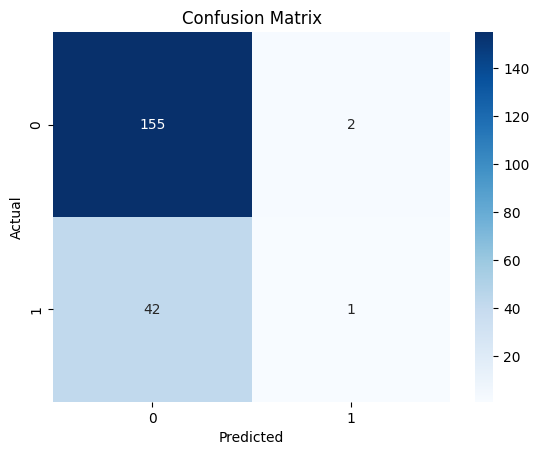

In [60]:
# data visualization
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Decision Tree Classifier for Churn Prediction

In [61]:
# train the model
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [62]:
# apply the model to make a prediciton
y_dt_train_pred = dt.predict(X_train)
y_dt_test_pred = dt.predict(X_test)

In [63]:
# evaluate model performance

# accuracy
train_acc = accuracy_score(y_train, y_dt_train_pred)
test_acc = accuracy_score(y_test, y_dt_test_pred)

# precision / recall / f1
train_prec = precision_score(y_train, y_dt_train_pred)
train_recall = recall_score(y_train, y_dt_train_pred)
train_f1 = f1_score(y_train, y_dt_train_pred)

# ROC AUC
y_dt_test_prob = dt.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_dt_test_prob)

# confusion matrix
conf_matrix = confusion_matrix(y_test, y_dt_test_pred)

print("Decision Tree Metrics")
print("Accuracy (Train):", train_acc)
print("Accuracy (Test):", test_acc)
print("Precision (Train):", train_prec)
print("Recall (Train):", train_recall)
print("F1 (Test):", f1_score(y_test, y_dt_test_pred))
print("ROC AUC (Test):", roc_auc)
print("Confusion Matrix:\n", conf_matrix)

Decision Tree Metrics
Accuracy (Train): 1.0
Accuracy (Test): 0.75
Precision (Train): 1.0
Recall (Train): 1.0
F1 (Test): 0.358974358974359
ROC AUC (Test): 0.5959117167826989
Confusion Matrix:
 [[136  21]
 [ 29  14]]


In [64]:
# display results
dt_results = pd.DataFrame(['Decision Tree', train_acc, test_acc, f1_score(y_test, y_dt_test_pred), roc_auc]).transpose()
dt_results.columns = ['Method', 'Training Accuracy', 'Test Accuracy', 'F1 Score', 'ROC AUC']
dt_results

,Method,Training Accuracy,Test Accuracy,F1 Score,ROC AUC
0,Decision Tree,1.0,0.75,0.358974,0.595912


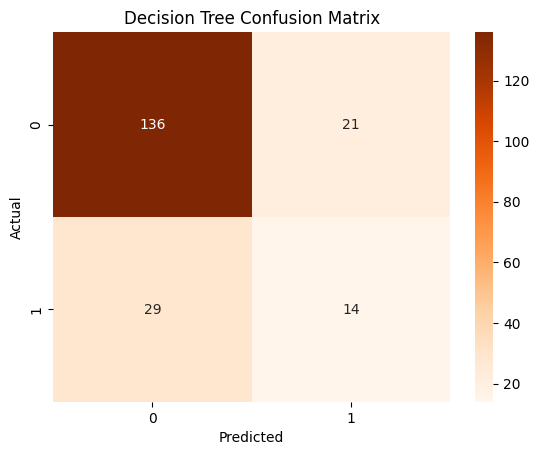

In [65]:
# data visualization
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix')
plt.show()

## Clustering for Customer Segmentation

In [66]:
# train the model
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans.fit(X_train)

KMeans(n_clusters=3, random_state=42)

In [67]:
# apply the model to cluster
y_kmeans_train_pred = kmeans.predict(X_train)
y_kmeans_test_pred = kmeans.predict(X_test)

In [68]:
# evaluate model performance
from sklearn.metrics import silhouette_score

kmeans_inertia = kmeans.inertia_
silhouette_avg = silhouette_score(X_train, y_kmeans_train_pred)

print(f'K-Means Inertia (Train): {kmeans_inertia}')
print(f'K-Means Silhouette Score (Train): {silhouette_avg}')

K-Means Inertia (Train): 72498880.98941483
K-Means Silhouette Score (Train): 0.42321437659782046


In [69]:
# display results
kmeans_results = pd.DataFrame(['K-Means Clustering', kmeans_inertia, silhouette_avg,]).transpose()
kmeans_results.columns = ['Method', 'Inertia (Train)', 'Silhouette Score (Train)']
kmeans_results

,Method,Inertia (Train),Silhouette Score (Train)
0,K-Means Clustering,72498880.989415,0.423214


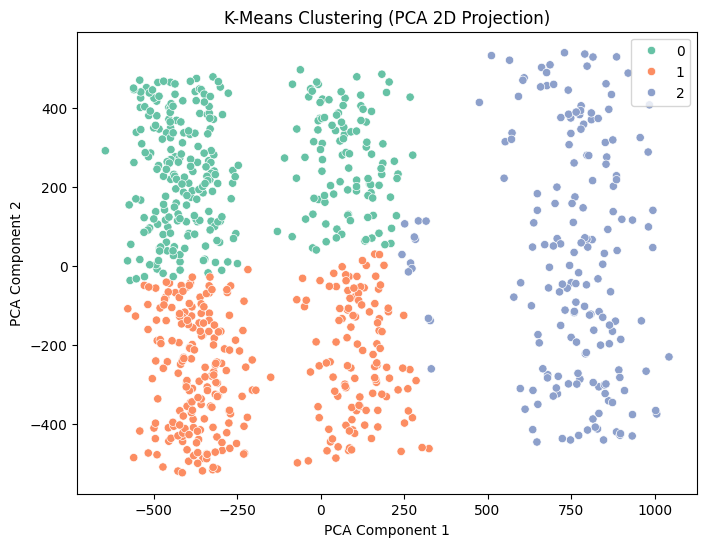

In [70]:
# data visualization
from sklearn.decomposition import PCA

# reduce X to 2 dimensions
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_kmeans_train_pred, palette='Set2')
plt.title('K-Means Clustering (PCA 2D Projection)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()